# Grid Plot: All Sessions × 5 Voltages

This notebook visualizes all session folders in `sample_outputs` as rows, and all 5 voltage types as columns, using matplotlib. Each subplot shows the raw spectrum for a given session and voltage type.

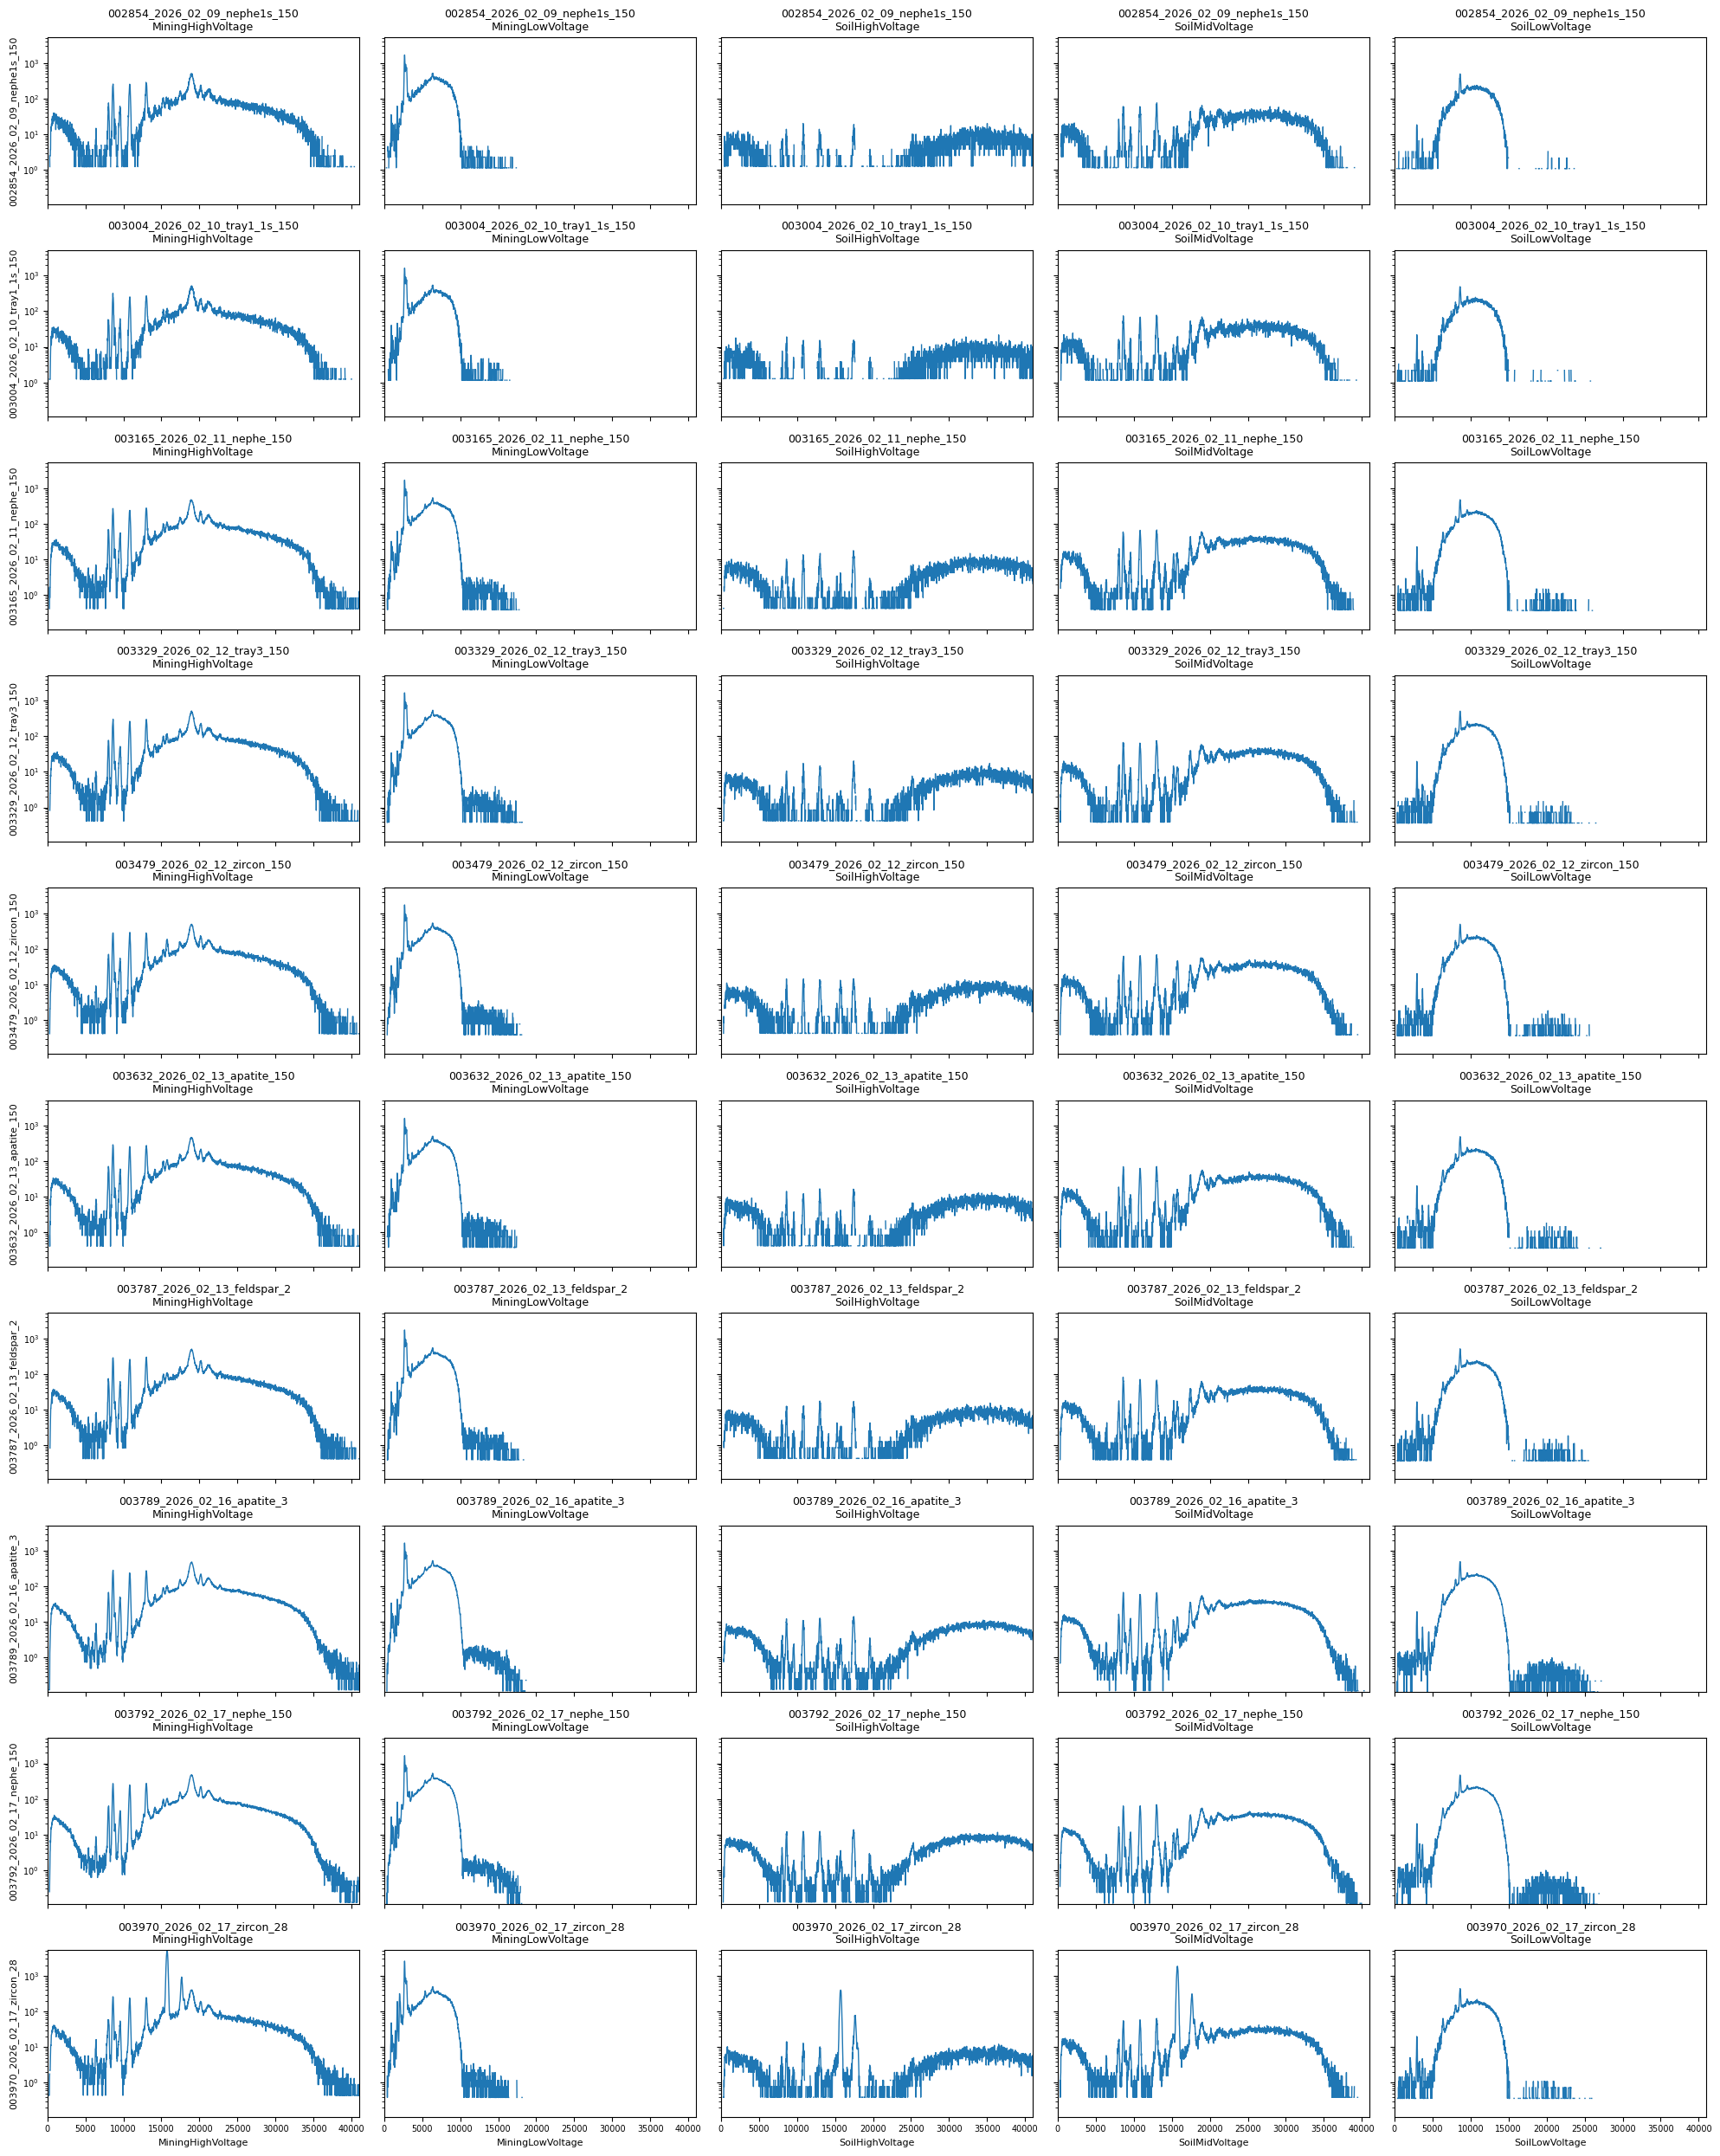

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd
# from pathlib import Path
# import re
# import numpy as np

# # Define the voltage types (for matching in filenames)
# voltage_types = [
#     "MiningHighVoltage",
#     "MiningLowVoltage",
#     "SoilHighVoltage",
#     "SoilMidVoltage",
#     "SoilLowVoltage",
# ]

# # Find all session folders in sample_outputs (6-digit prefix)
# sample_outputs = Path(r"C:\Users\phuynh\Projects\robotray-main\robotray_v2\sample_outputs_v2")
# session_folders = sorted([f for f in sample_outputs.iterdir() if f.is_dir() and re.match(r"^\d{6}", f.name)])

# n_sessions = len(session_folders)
# n_voltages = len(voltage_types)

# # First pass: find global x/y limits
# x_min, x_max = np.inf, -np.inf
# y_min, y_max = np.inf, -np.inf
# all_data = []

# for session in session_folders:
#     session_data = []
#     for vtype in voltage_types:
#         csv_files = list(session.glob(f"*{vtype}*.csv"))
#         if csv_files:
#             csv_path = csv_files[0]
#             try:
#                 df = pd.read_csv(csv_path)
#                 energy_col = [c for c in df.columns if 'energy' in c.lower()][0]
#                 intensity_col = [c for c in df.columns if 'intensity' in c.lower() or 'counts' in c.lower()][0]
#                 x = df[energy_col].values
#                 y = df[intensity_col].values
#                 # Avoid log(0) and negative values for y
#                 y = np.where(y > 0, y, np.nan)
#                 x_min = min(x_min, np.nanmin(x))
#                 x_max = max(x_max, np.nanmax(x))
#                 y_min = min(y_min, np.nanmin(y))
#                 y_max = max(y_max, np.nanmax(y))
#                 session_data.append((x, y))
#             except Exception:
#                 session_data.append((None, None))
#         else:
#             session_data.append((None, None))
#     all_data.append(session_data)

# if n_sessions == 0:
#     print("No session folders found in ../sample_outputs. Please check the path and folder names.")
# else:
#     fig, axes = plt.subplots(n_sessions, n_voltages, figsize=(n_voltages*4, n_sessions*2.5), sharex=True, sharey=True)

#     for row in range(n_sessions):
#         for col in range(n_voltages):
#             ax = axes[row, col] if n_sessions > 1 else axes[col]
#             x, y = all_data[row][col]
#             if x is not None and y is not None:
#                 ax.plot(x, y, lw=1)
#                 ax.set_title(f"{session_folders[row].name}\n{voltage_types[col]}", fontsize=9)
#             else:
#                 ax.text(0.5, 0.5, "No file", ha='center', va='center', fontsize=8)
#             if col == 0:
#                 ax.set_ylabel(session_folders[row].name, fontsize=8)
#             else:
#                 ax.set_ylabel("")
#             if row == n_sessions - 1:
#                 ax.set_xlabel(voltage_types[col], fontsize=8)
#             else:
#                 ax.set_xlabel("")
#             ax.tick_params(labelsize=7)
#             ax.set_yscale('log')
#             ax.set_xlim(x_min, x_max)
#             ax.set_ylim(y_min, y_max)

#     plt.tight_layout()
#     plt.show()


c:\Users\phuynh\AppData\Local\miniconda3\envs\vis_explore\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


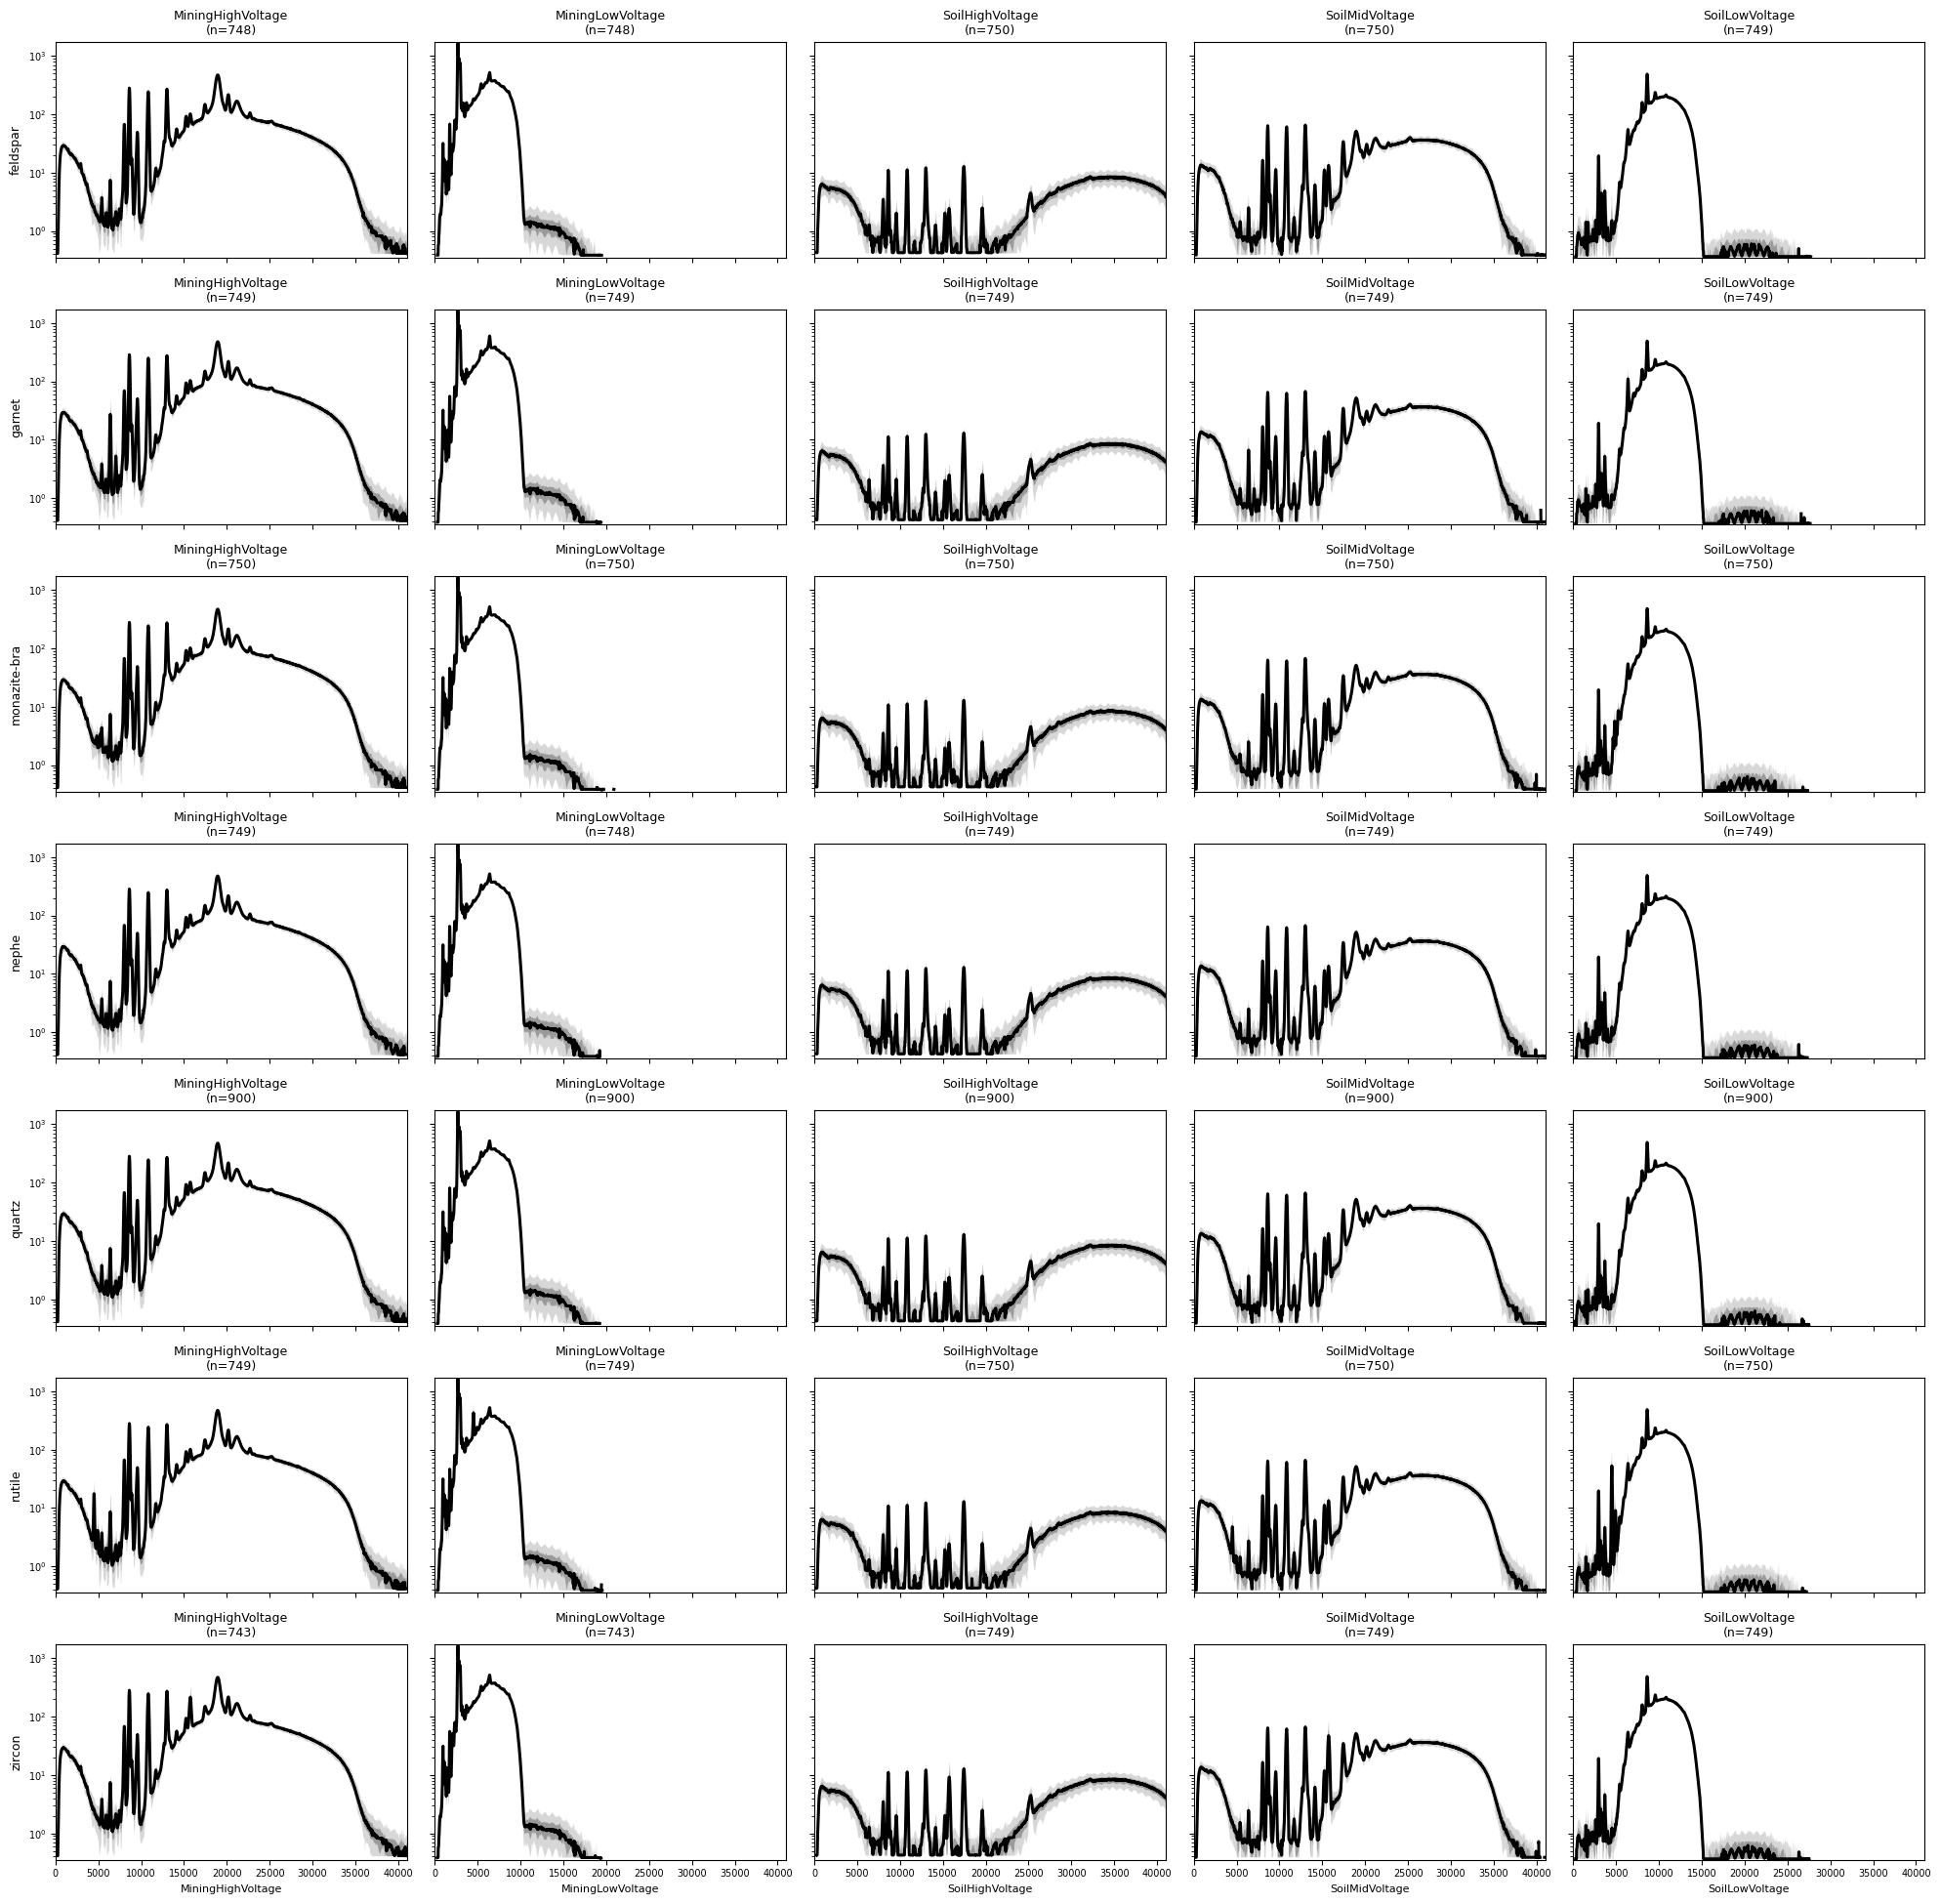

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import re
import numpy as np
from collections import defaultdict

# Define the voltage types (for matching in filenames)
voltage_types = [
    "MiningHighVoltage",
    "MiningLowVoltage",
    "SoilHighVoltage",
    "SoilMidVoltage",
    "SoilLowVoltage",
]


def extract_mineral(session_name: str):
    """Extract mineral from folder names like 003165_2026_02_11_nephe_150."""
    m = re.match(r"^\d{6}_\d{4}_\d{2}_\d{2}_(.+)_\d+$", session_name)
    return m.group(1) if m else None


sample_outputs = Path(r"C:\Users\phuynh\Projects\robotray-main\robotray_v2\sample_outputs_v2")
session_folders = sorted(
    [f for f in sample_outputs.iterdir() if f.is_dir() and re.match(r"^\d{6}", f.name)]
)

# Group sessions by mineral so each row is one mineral.
mineral_to_sessions = defaultdict(list)
for session in session_folders:
    mineral = extract_mineral(session.name)
    if mineral:
        mineral_to_sessions[mineral].append(session)

minerals = sorted(mineral_to_sessions.keys())
n_minerals = len(minerals)
n_voltages = len(voltage_types)

# Collect all curves for each (mineral, voltage).
curves = {(mineral, vtype): [] for mineral in minerals for vtype in voltage_types}

for mineral in minerals:
    for session in mineral_to_sessions[mineral]:
        for vtype in voltage_types:
            csv_files = sorted(session.glob(f"*{vtype}*.csv"))
            for csv_path in csv_files:
                try:
                    df = pd.read_csv(csv_path)
                    energy_candidates = [c for c in df.columns if "energy" in c.lower()]
                    intensity_candidates = [
                        c for c in df.columns if "intensity" in c.lower() or "counts" in c.lower()
                    ]
                    if not energy_candidates or not intensity_candidates:
                        continue

                    x = df[energy_candidates[0]].to_numpy(dtype=float)
                    y = df[intensity_candidates[0]].to_numpy(dtype=float)

                    valid = np.isfinite(x) & np.isfinite(y)
                    x = x[valid]
                    y = y[valid]
                    if x.size == 0:
                        continue

                    sort_idx = np.argsort(x)
                    x = x[sort_idx]
                    y = y[sort_idx]
                    y = np.where(y > 0, y, np.nan)
                    curves[(mineral, vtype)].append((x, y))
                except Exception:
                    continue

if n_minerals == 0:
    print("No valid mineral session folders found in ../sample_outputs.")
else:
    summary = {}
    global_x_min, global_x_max = np.inf, -np.inf
    global_y_min, global_y_max = np.inf, -np.inf

    for mineral in minerals:
        for vtype in voltage_types:
            panel_curves = curves[(mineral, vtype)]
            if not panel_curves:
                summary[(mineral, vtype)] = None
                continue

            # Interpolate each curve to overlapping x-range for percentile envelopes.
            x_lows = [np.nanmin(x) for x, _ in panel_curves]
            x_highs = [np.nanmax(x) for x, _ in panel_curves]
            x_min = np.nanmax(x_lows)
            x_max = np.nanmin(x_highs)

            if not np.isfinite(x_min) or not np.isfinite(x_max) or x_max <= x_min:
                summary[(mineral, vtype)] = None
                continue

            n_points = int(np.median([len(x) for x, _ in panel_curves]))
            n_points = max(100, min(2000, n_points))
            x_grid = np.linspace(x_min, x_max, n_points)

            y_matrix = np.asarray([np.interp(x_grid, x, y) for x, y in panel_curves])
            if y_matrix.size == 0:
                summary[(mineral, vtype)] = None
                continue

            q05 = np.nanpercentile(y_matrix, 5, axis=0)
            q25 = np.nanpercentile(y_matrix, 25, axis=0)
            q50 = np.nanpercentile(y_matrix, 50, axis=0)
            q75 = np.nanpercentile(y_matrix, 75, axis=0)
            q95 = np.nanpercentile(y_matrix, 95, axis=0)

            q05 = np.where(q05 > 0, q05, np.nan)
            q25 = np.where(q25 > 0, q25, np.nan)
            q50 = np.where(q50 > 0, q50, np.nan)
            q75 = np.where(q75 > 0, q75, np.nan)
            q95 = np.where(q95 > 0, q95, np.nan)

            summary[(mineral, vtype)] = {
                "x": x_grid,
                "q05": q05,
                "q25": q25,
                "q50": q50,
                "q75": q75,
                "q95": q95,
                "n": len(panel_curves),
            }

            global_x_min = min(global_x_min, x_min)
            global_x_max = max(global_x_max, x_max)
            global_y_min = min(global_y_min, np.nanmin(q05))
            global_y_max = max(global_y_max, np.nanmax(q95))

    fig, axes = plt.subplots(
        n_minerals,
        n_voltages,
        figsize=(n_voltages * 4, n_minerals * 2.8),
        sharex=True,
        sharey=True,
    )

    if n_minerals == 1:
        axes = np.array([axes])

    for row, mineral in enumerate(minerals):
        for col, vtype in enumerate(voltage_types):
            ax = axes[row, col]
            stats = summary[(mineral, vtype)]

            if stats is None:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=8)
            else:
                x = stats["x"]
                ax.fill_between(x, stats["q05"], stats["q95"], color="lightgray", alpha=0.9, lw=0)
                ax.fill_between(x, stats["q25"], stats["q75"], color="gray", alpha=0.7, lw=0)
                ax.plot(x, stats["q50"], color="black", lw=2.2)
                ax.set_title(f"{vtype}\n(n={stats['n']})", fontsize=9)

            if col == 0:
                ax.set_ylabel(mineral, fontsize=9)
            else:
                ax.set_ylabel("")

            if row == n_minerals - 1:
                ax.set_xlabel(vtype, fontsize=8)
            else:
                ax.set_xlabel("")

            ax.tick_params(labelsize=7)
            ax.set_yscale("log")

            if np.isfinite(global_x_min) and np.isfinite(global_x_max):
                ax.set_xlim(global_x_min, global_x_max)
            if np.isfinite(global_y_min) and np.isfinite(global_y_max) and global_y_max > global_y_min:
                ax.set_ylim(global_y_min, global_y_max)

    plt.tight_layout()
    plt.show()
